Student Name : Vinay Gawli
Student id: A00083026

In [ ]:
!pip -q install --upgrade pip
!pip -q install grad-cam

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 21.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget


In [ ]:
from google.colab import files
uploaded = files.upload()   # upload archive.zip
zip_name = list(uploaded.keys())[0]
print("Uploaded:", zip_name)


Saving archive.zip to archive (1).zip
Uploaded: archive (1).zip


In [ ]:
import os, zipfile, shutil, glob

DATA_DIR = "/content/dr_data"
shutil.rmtree(DATA_DIR, ignore_errors=True)
os.makedirs(DATA_DIR, exist_ok=True)

with zipfile.ZipFile(zip_name, "r") as z:
    z.extractall(DATA_DIR)

print("Top-level:", os.listdir(DATA_DIR)[:20])

imgs = glob.glob(DATA_DIR + "/**/*.jpg", recursive=True) + \
       glob.glob(DATA_DIR + "/**/*.jpeg", recursive=True) + \
       glob.glob(DATA_DIR + "/**/*.png", recursive=True)

print("Total images found:", len(imgs))
print("Sample files:", imgs[:5])


Top-level: ['resized']
Total images found: 2999
Sample files: ['/content/dr_data/resized/label_0_329.jpeg', '/content/dr_data/resized/label_0_2155.jpeg', '/content/dr_data/resized/label_0_594.jpeg', '/content/dr_data/resized/label_3_2741.jpeg', '/content/dr_data/resized/label_3_1767.jpeg']


In [ ]:
import pandas as pd, re, os, glob

imgs = glob.glob(DATA_DIR + "/**/*.jpg", recursive=True) + \
       glob.glob(DATA_DIR + "/**/*.jpeg", recursive=True) + \
       glob.glob(DATA_DIR + "/**/*.png", recursive=True)

pattern = re.compile(r"label_(\d+)_", re.IGNORECASE)

rows = []
bad = 0
for p in imgs:
    name = os.path.basename(p)
    m = pattern.search(name)
    if not m:
        bad += 1
        continue
    y5 = int(m.group(1))
    y = 0 if y5 == 0 else 1
    rows.append((p, y))

df = pd.DataFrame(rows, columns=["path", "label"])
print("Rows:", len(df), "| Unlabeled files skipped:", bad)
print("Classes:", sorted(df["label"].unique()))
print(df.head())

print("\nBinary class distribution (0=No DR, 1=DR):\n", df["label"].value_counts().sort_index())

Rows: 2999 | Unlabeled files skipped: 0
Classes: [np.int64(0), np.int64(1)]
                                         path  label
0   /content/dr_data/resized/label_0_329.jpeg      0
1  /content/dr_data/resized/label_0_2155.jpeg      0
2   /content/dr_data/resized/label_0_594.jpeg      0
3  /content/dr_data/resized/label_3_2741.jpeg      1
4  /content/dr_data/resized/label_3_1767.jpeg      1

Binary class distribution (0=No DR, 1=DR):
 label
0    2167
1     832
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

SEED = 42
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df["label"], random_state=SEED)
val_df, test_df   = train_test_split(temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED)

print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))

Train: 2099 Val: 450 Test: 450


In [ ]:
import cv2, numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

IMG_SIZE = 224

def read_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

train_tfms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.485,0.456,0.406), (0.229,0.224,0.225)),
])

val_tfms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize((0.485,0.456,0.406), (0.229,0.224,0.225)),
])

class DRDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = read_image(row["path"])
        y = int(row["label"])
        if self.transform:
            img = self.transform(img)
        return img, y


DEVICE: cuda


In [ ]:
BATCH_SIZE = 32

train_loader = DataLoader(DRDataset(train_df, train_tfms), batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(DRDataset(val_df, val_tfms),   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(DRDataset(test_df, val_tfms),  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)


In [ ]:
import timm
import torch
import torch.nn as nn
import numpy as np

NUM_CLASSES = df["label"].nunique()   # ✅ should now be 2
MODEL_NAME = "resnet18"   # use "resnet50" if GPU is available

model = timm.create_model(MODEL_NAME, pretrained=True, num_classes=NUM_CLASSES).to(DEVICE)

# class weights to handle imbalance
counts = train_df["label"].value_counts().sort_index().values
weights = 1.0 / counts
weights = weights / weights.sum() * NUM_CLASSES
class_weights = torch.tensor(weights, dtype=torch.float32).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", patience=2, factor=0.5
)

print("NUM_CLASSES:", NUM_CLASSES)   # should print 2
print("Train class counts:", counts)
print("Class weights:", class_weights.detach().cpu().numpy())
print("Model:", MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

NUM_CLASSES: 2
Train class counts: [1517  582]
Class weights: [0.5545498 1.4454502]
Model: resnet18


In [ ]:
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score

def run_epoch(loader, train=True):
    model.train() if train else model.eval()

    total_loss = 0.0
    all_preds, all_targets = [], []

    for x, y in tqdm(loader, leave=False):
        x, y = x.to(DEVICE), y.to(DEVICE)

        if train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(train):
            logits = model(x)
            loss = criterion(logits, y)

            if train:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * x.size(0)

        preds = torch.argmax(logits, dim=1)
        all_preds.append(preds.detach().cpu().numpy())
        all_targets.append(y.detach().cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    f1  = f1_score(all_targets, all_preds, average="macro")
    qwk = cohen_kappa_score(all_targets, all_preds, weights="quadratic")

    return avg_loss, acc, f1, qwk, all_targets, all_preds


In [ ]:
EPOCHS = 20
best_val_acc = -1
best_path = "/content/best_dr_model_binary.pth"

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc, tr_f1, tr_qwk, _, _ = run_epoch(train_loader, train=True)
    va_loss, va_acc, va_f1, va_qwk, _, _ = run_epoch(val_loader, train=False)

    # ✅ step scheduler on validation accuracy (or use va_f1)
    scheduler.step(va_acc)

    lr_now = optimizer.param_groups[0]["lr"]

    print(f"Epoch {epoch}/{EPOCHS} | "
          f"Train: loss {tr_loss:.4f} acc {tr_acc:.4f} f1 {tr_f1:.4f} || "
          f"Val: loss {va_loss:.4f} acc {va_acc:.4f} f1 {va_f1:.4f} | "
          f"LR {lr_now:.2e}")

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save(model.state_dict(), best_path)
        print("✅ Saved best model:", best_path)

Epoch 1/20 | Train: loss 0.6922 acc 0.5641 f1 0.5133 || Val: loss 0.6851 acc 0.4911 f1 0.4884 | LR 1.00e-04
✅ Saved best model: /content/best_dr_model_binary.pth


Epoch 2/20 | Train: loss 0.6781 acc 0.6198 f1 0.5777 || Val: loss 0.6709 acc 0.5600 f1 0.5441 | LR 1.00e-04
✅ Saved best model: /content/best_dr_model_binary.pth


Epoch 3/20 | Train: loss 0.6660 acc 0.6727 f1 0.6044 || Val: loss 0.6666 acc 0.5667 f1 0.5529 | LR 1.00e-04
✅ Saved best model: /content/best_dr_model_binary.pth


Epoch 4/20 | Train: loss 0.6474 acc 0.6565 f1 0.6191 || Val: loss 0.6645 acc 0.5533 f1 0.5419 | LR 1.00e-04


Epoch 5/20 | Train: loss 0.6266 acc 0.6732 f1 0.6382 || Val: loss 0.6581 acc 0.6133 f1 0.5906 | LR 1.00e-04
✅ Saved best model: /content/best_dr_model_binary.pth


...

Epoch 16/20 | Train: loss 0.3939 acc 0.8409 f1 0.8166 || Val: loss 0.7084 acc 0.6067 f1 0.5690 | LR 2.50e-05


Epoch 17/20 | Train: loss 0.3772 acc 0.8437 f1 0.8179 || Val: loss 0.7152 acc 0.6400 f1 0.5950 | LR 2.50e-05


Epoch 18/20 | Train: loss 0.3699 acc 0.8409 f1 0.8161 || Val: loss 0.7206 acc 0.6489 f1 0.6023 | LR 2.50e-05


Epoch 19/20 | Train: loss 0.3639 acc 0.8509 f1 0.8252 || Val: loss 0.7281 acc 0.6578 f1 0.6124 | LR 2.50e-05
✅ Saved best model: /content/best_dr_model_binary.pth


Epoch 20/20 | Train: loss 0.3540 acc 0.8580 f1 0.8352 || Val: loss 0.7386 acc 0.6444 f1 0.5944 | LR 2.50e-05


TEST loss: 0.7620810728602939
TEST acc : 0.6733333333333333
TEST f1  : 0.6366402821187469
TEST qwk : 0.2860226659471129

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.69      0.75       325
           1       0.44      0.64      0.52       125

    accuracy                           0.67       450
   macro avg       0.64      0.66      0.64       450
weighted avg       0.72      0.67      0.69       450



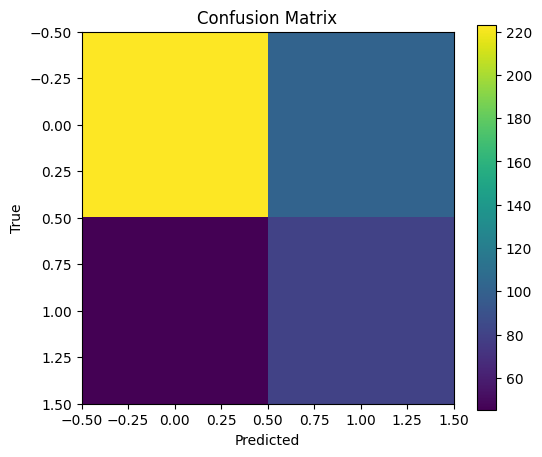

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

model.load_state_dict(torch.load(best_path, map_location=DEVICE))

te_loss, te_acc, te_f1, te_qwk, y_true, y_pred = run_epoch(test_loader, train=False)
print("TEST loss:", te_loss)
print("TEST acc :", te_acc)
print("TEST f1  :", te_f1)
print("TEST qwk :", te_qwk)

print("\nClassification Report:\n", classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.show()


In [ ]:
import torch
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt

class SimpleGradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hook_handles = []
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, inp, out):
            self.activations = out.detach()

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        self.hook_handles.append(self.target_layer.register_forward_hook(forward_hook))
        self.hook_handles.append(self.target_layer.register_full_backward_hook(backward_hook))

    def remove_hooks(self):
        for h in self.hook_handles:
            h.remove()

    def __call__(self, x, class_idx=None):
        self.model.zero_grad(set_to_none=True)
        logits = self.model(x)

        if class_idx is None:
            class_idx = int(torch.argmax(logits, dim=1).item())

        score = logits[:, class_idx].sum()
        score.backward(retain_graph=True)

        grads = self.gradients
        acts  = self.activations

        weights = grads.mean(dim=(2, 3), keepdim=True)
        cam = (weights * acts).sum(dim=1)
        cam = torch.relu(cam)

        cam = cam[0].cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx

def overlay_cam(rgb_img_0to1, cam_0to1):
    h, w, _ = rgb_img_0to1.shape
    cam_resized = cv2.resize(cam_0to1, (w, h))
    heatmap = cv2.applyColorMap((cam_resized * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    overlay = np.clip(0.6 * rgb_img_0to1 + 0.4 * heatmap, 0, 1)
    return overlay


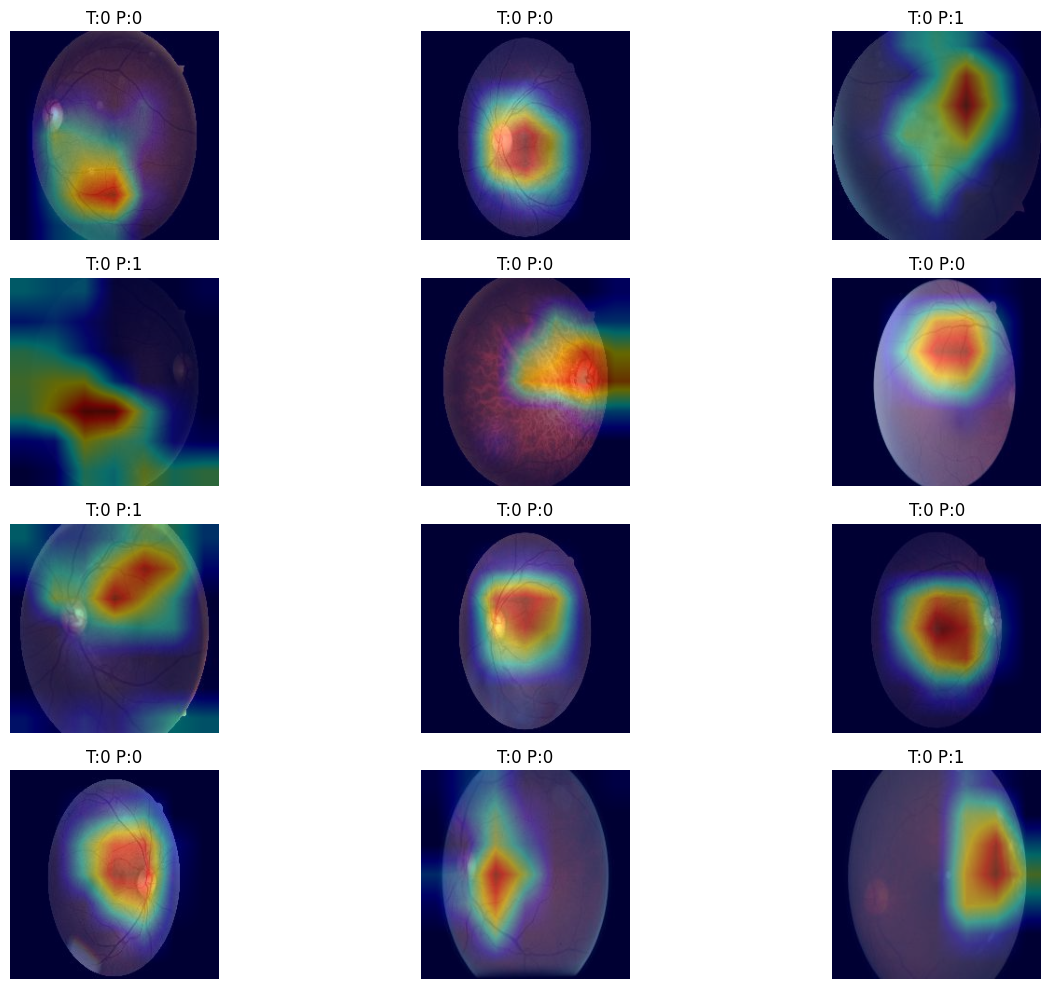

Saved Grad-CAM overlays in /content/gradcam_outputs


In [ ]:
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt

# pick target layer based on model
if MODEL_NAME == "resnet18":
    target_layer = model.layer4[-1].conv2
else:
    target_layer = model.layer4[-1].conv3

cam = SimpleGradCAM(model, target_layer)

mean = np.array([0.485,0.456,0.406])
std  = np.array([0.229,0.224,0.225])

def denorm(img_tensor):
    img = img_tensor.detach().cpu().numpy().transpose(1,2,0)
    img = (img * std) + mean
    return np.clip(img, 0, 1)

os.makedirs("/content/gradcam_outputs", exist_ok=True)

test_ds = DRDataset(test_df, val_tfms)
idxs = np.random.choice(len(test_ds), size=min(12, len(test_ds)), replace=False)

plt.figure(figsize=(14, 10))
for i, idx in enumerate(idxs, 1):
    x, y = test_ds[idx]
    inp = x.unsqueeze(0).to(DEVICE)

    cam_map, pred = cam(inp)
    rgb = denorm(x)
    overlay = overlay_cam(rgb, cam_map)

    out = f"/content/gradcam_outputs/{idx}_T{y}_P{pred}.png"
    cv2.imwrite(out, cv2.cvtColor((overlay*255).astype(np.uint8), cv2.COLOR_RGB2BGR))

    plt.subplot(4,3,i)
    plt.imshow(overlay)
    plt.title(f"T:{y} P:{pred}")
    plt.axis("off")

plt.tight_layout()
plt.show()
print("Saved Grad-CAM overlays in /content/gradcam_outputs")


In [ ]:
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support

prec, rec, f1, sup = precision_recall_fscore_support(y_true, y_pred, labels=sorted(df["label"].unique()), zero_division=0)

metrics_table = pd.DataFrame({
    "class": sorted(df["label"].unique()),
    "precision": prec,
    "recall": rec,
    "f1": f1,
    "support": sup
})

metrics_table


,class,precision,recall,f1,support
0,0,0.83209,0.686154,0.752108,325
1,1,0.43956,0.640000,0.521173,125


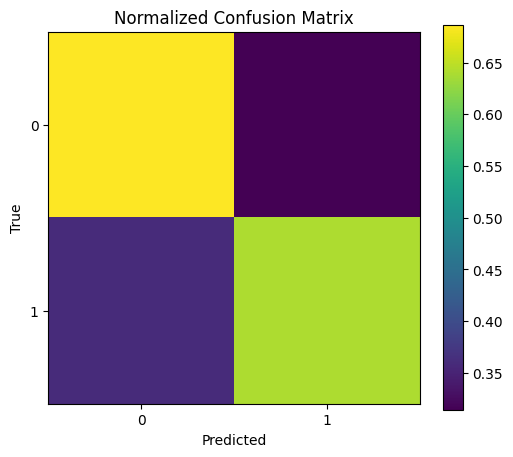

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

labels_sorted = sorted(df["label"].unique())
cm = confusion_matrix(y_true, y_pred, labels=labels_sorted)
cm_norm = cm / (cm.sum(axis=1, keepdims=True) + 1e-9)

plt.figure(figsize=(6,5))
plt.imshow(cm_norm)
plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.xticks(range(len(labels_sorted)), labels_sorted)
plt.yticks(range(len(labels_sorted)), labels_sorted)
plt.show()


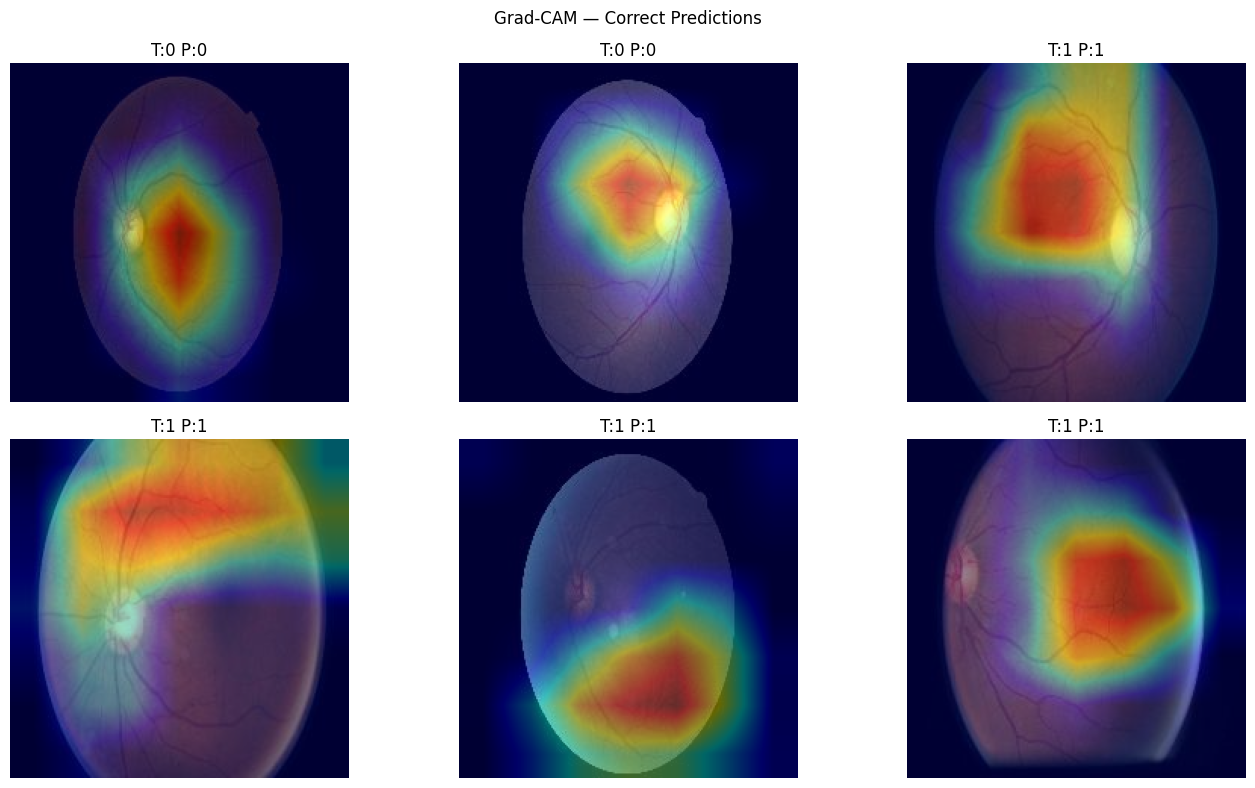

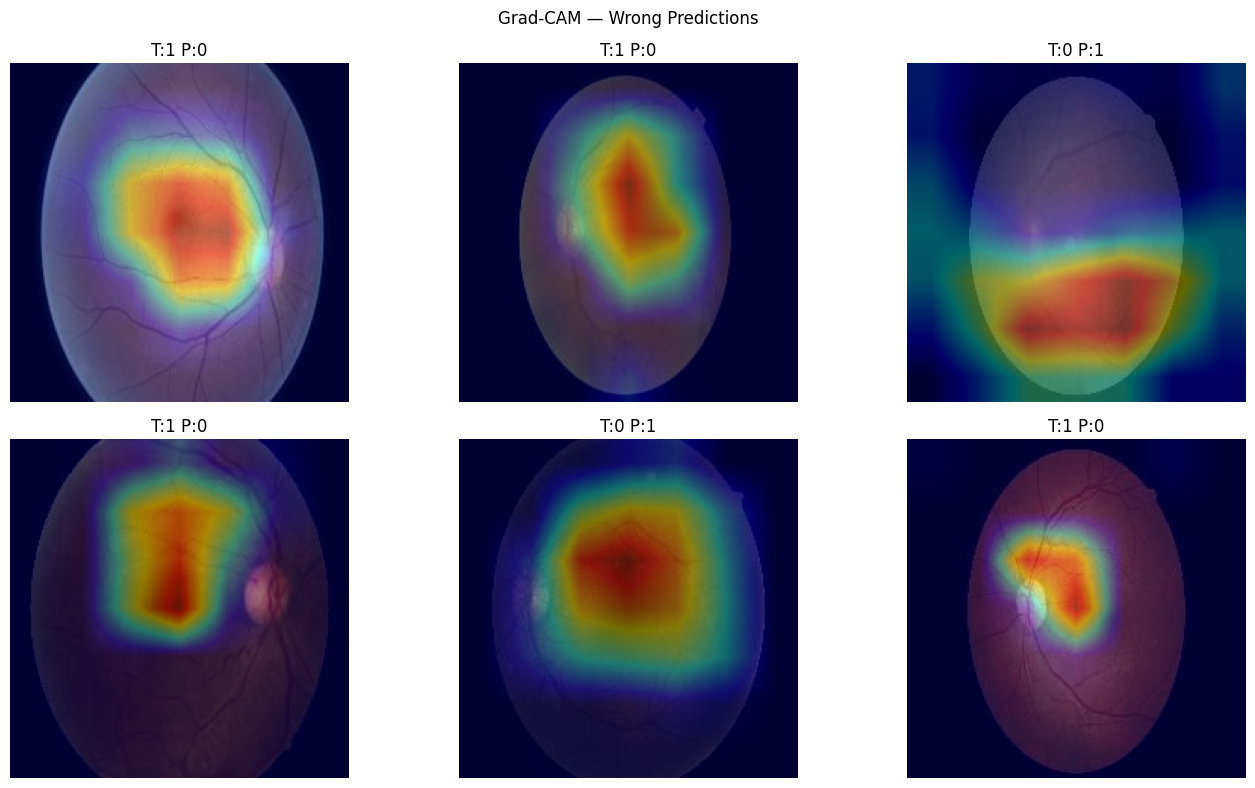

Saved to /content/gradcam_cases/correct and /content/gradcam_cases/wrong


In [ ]:
import os, numpy as np, cv2, matplotlib.pyplot as plt
import torch

os.makedirs("/content/gradcam_cases/correct", exist_ok=True)
os.makedirs("/content/gradcam_cases/wrong", exist_ok=True)

# Use same helper functions: denorm(), overlay_cam(), and cam = SimpleGradCAM(...)
test_ds = DRDataset(test_df, val_tfms)

def predict_single(x):
    inp = x.unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        pred = int(torch.argmax(model(inp), dim=1).item())
    return pred

# collect some correct and wrong indices
correct_idxs, wrong_idxs = [], []
for i in range(len(test_ds)):
    x, y = test_ds[i]
    pred = predict_single(x)
    if pred == y and len(correct_idxs) < 6:
        correct_idxs.append(i)
    if pred != y and len(wrong_idxs) < 6:
        wrong_idxs.append(i)
    if len(correct_idxs) == 6 and len(wrong_idxs) == 6:
        break

def save_cam_panel(idxs, out_dir, title):
    plt.figure(figsize=(14, 8))
    for k, idx in enumerate(idxs, 1):
        x, y = test_ds[idx]
        inp = x.unsqueeze(0).to(DEVICE)

        cam_map, pred = cam(inp)   # from SimpleGradCAM
        rgb = denorm(x)
        overlay = overlay_cam(rgb, cam_map)

        out_path = os.path.join(out_dir, f"{idx}_T{y}_P{pred}.png")
        cv2.imwrite(out_path, cv2.cvtColor((overlay*255).astype(np.uint8), cv2.COLOR_RGB2BGR))

        plt.subplot(2, 3, k)
        plt.imshow(overlay)
        plt.title(f"T:{y} P:{pred}")
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

save_cam_panel(correct_idxs, "/content/gradcam_cases/correct", "Grad-CAM — Correct Predictions")
save_cam_panel(wrong_idxs, "/content/gradcam_cases/wrong", "Grad-CAM — Wrong Predictions")

print("Saved to /content/gradcam_cases/correct and /content/gradcam_cases/wrong")


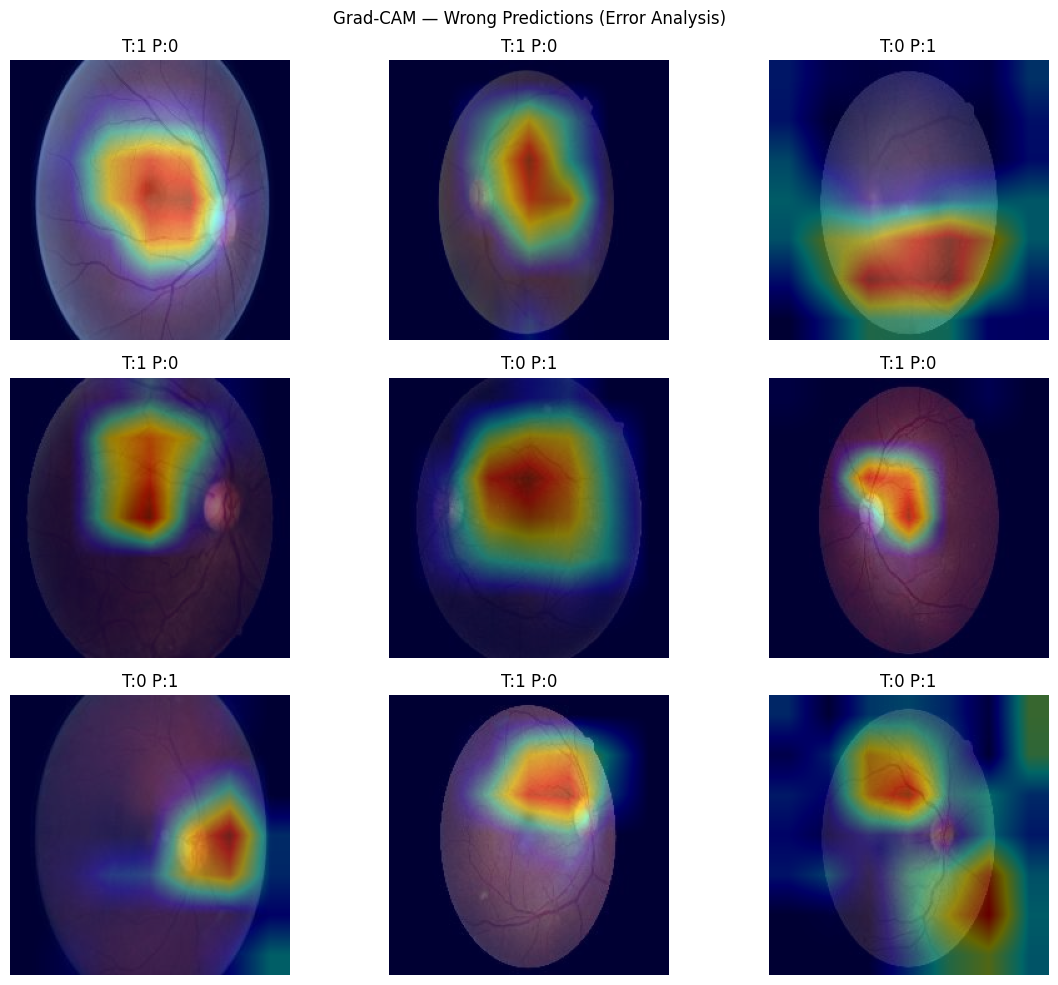

Saved to /content/gradcam_cases/wrong


In [ ]:
import os, numpy as np, cv2, matplotlib.pyplot as plt
import torch

os.makedirs("/content/gradcam_cases/wrong", exist_ok=True)

test_ds = DRDataset(test_df, val_tfms)

def predict_single(x):
    inp = x.unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        return int(torch.argmax(model(inp), dim=1).item())

wrong_idxs = []
for i in range(len(test_ds)):
    x, y = test_ds[i]
    pred = predict_single(x)
    if pred != y:
        wrong_idxs.append(i)
    if len(wrong_idxs) == 9:
        break

plt.figure(figsize=(12, 10))
for k, idx in enumerate(wrong_idxs, 1):
    x, y = test_ds[idx]
    inp = x.unsqueeze(0).to(DEVICE)

    cam_map, pred = cam(inp)
    rgb = denorm(x)
    overlay = overlay_cam(rgb, cam_map)

    out_path = f"/content/gradcam_cases/wrong/{idx}_T{y}_P{pred}.png"
    cv2.imwrite(out_path, cv2.cvtColor((overlay*255).astype(np.uint8), cv2.COLOR_RGB2BGR))

    plt.subplot(3, 3, k)
    plt.imshow(overlay)
    plt.title(f"T:{y} P:{pred}")
    plt.axis("off")

plt.suptitle("Grad-CAM — Wrong Predictions (Error Analysis)")
plt.tight_layout()
plt.show()

print("Saved to /content/gradcam_cases/wrong")


Hugging face deployed model link : https://huggingface.co/spaces/gawliv/gawliv_diabetic_retinopathy


Dataset Link: https://www.kaggle.com/datasets/waleedashraf9t/diabetic-retinopathy-fundus-images-resized


Youtube Link : https://youtu.be/Fs8gFqKymWY